## **Assignment: "DeepLearning Foundations" - SLP to MLP**

### The Scenario

Your team at "NeuralLink Solutions" is moving beyond simple logical gates. You are now tasked with building a Multi-Layered Perceptron (MLP) to solve the ExOR problem and perform complex classification. You need to understand how "Hidden Layers" act as feature extractors and how the choice of "Activation Functions" determines the network's ability to converge.

### **Part 1: Conceptual Stress-Tests**

**Question 1:**
According to the lecture, every boolean function (including complex ones like ExOR) can be represented by a network of perceptrons that is at most:
> Remember the "Linear Wall" from the last assignment. An MLP solves ExOR by drawing multiple lines and combining them. Think about how many layers/neurons are minimum.

A) 1 Level deep (Single Layer)

B) 2 Levels deep (One Hidden, One Output)

C) 10 Levels deep (Deep Learning only)

D) Infinite levels deep

Answer: B) 2 Levels deep (One Hidden, One Output)

explaination : ExOR is not linearly seprable so it cannot be solved using single layer percptron but it can be solved using 2 layers i.e one hidden layer and one output layer with appropriate activation functions. the hidden layer can learn to extract features that allow output layer to classify the Exor correctly.

**Question 2:**
Suppose you build a 5-layer MLP but use Linear Activations ($\phi(x) = x$) for every single hidden layer. How will this network perform compared to a standard 1-layer Linear Perceptron?

> Activation functions are the "Non-linear Engines." Without them, an MLP—no matter how deep—collapses mathematically into a single linear transformation ($W_2(W_1x) = W_{new}x$).

A) It will be much more powerful because it has more weights to learn.

B) It will be exactly equivalent to a 1-layer Linear Perceptron because the composition of linear functions is still linear.

C) It will solve the XOR problem easily.

D) It will always return a zero output.

Answer : B) It will be exactly equivalent to a 1-layer Linear Perceptron because the composition of linear functions is still linear.

explaination : if all hidden layers use linear activations then entire network can be represented as a single linear transformation making it equivalent to a 1-layer linear perceptron. the network will not be able to learn complex patterns or solve non-linear problems like XOR.

**Question 3:**
When training very deep networks with a Sigmoid activation, we often encounter the "Vanishing Gradient" problem. Looking at the derivative of Sigmoid , what is the maximum possible value of the gradient that can be passed back through a single Sigmoid neuron?
>  Compare ReLU and Sigmoid. One "saturates" (flattens out) for large inputs, potentially killing gradients, while the other stays linear for positive values.

A) 1.0

B) 0.5

C) 0.25

D) Infinity

Answer: C) 0.25

explaination : The derivative of the Sigmoid function is given by $\sigma'(x) = \sigma(x)(1 - \sigma(x))$. The maximum value of this derivative occurs when $\sigma(x) = 0.5$, which gives $\sigma'(x) = 0.5 * (1 - 0.5) = 0.25$. This means that the maximum gradient that can be passed back through a single Sigmoid neuron is 0.25, which can lead to the vanishing gradient problem in deep networks.

ReLU is defined as $f(x) = max(0, x)$ which means it does not saturate for positive inputs and allows gradients to flow through. whereas the Sigmoid function saturates for large positive or negative inputs, leading to very small gradients and the vanishing gradient problem in deep networks.

### **Part 2: The Math of MLP Structure**
Look at the architecture on Slide 29. Total weights = (Inputs $\times$ Hidden) + (Hidden $\times$ Outputs) + Biases.




**Question 4:**
Consider an MLP with:

- 3 Input features
- 1 Hidden Layer with 4 neurons
- 1 Output Layer with 2 neurons (for 2-class classification)

Every neuron in the hidden and output layers has a bias.

How many total learnable parameters (weights + biases) exist in this network? (Show your calculation).

Answer: 
Total weights = (Inputs $\times$ Hidden) + (Hidden $\times$ Outputs) + Biases
= (3 $\times$ 4) + (4 $\times$ 2) + (4 + 2)  # Biases for hidden and output layers
= 12 + 8 + 6
= 26    

### **Part 3: Coding Challenge — Activation & Depth**

In this section, you will use a simple MLP to solve the non-linear "Spiral" dataset. You will experiment with how changing from Sigmoid to ReLU can affect results.

**Question 5:**
Which activation function produced a smoother,
more flexible boundary?



Answer 5: ReLU produced a smoother, more flexible boundary compared to Sigmoid.

explaination : ReLU allows for non-linear transformations without saturation enabling the network to learn more complex patterns. Sigmoid on the other hand can saturate for large positive or negative inputs leading to vanishing gradients and less flexible decision boundaries.

**Question 6:** Try adding more neurons: change (10, 10) to (100, 100).
Does the complexity of the boundary increase?

Answer: Yes, increasing the number of neurons allows the network to learn more complex patterns which can lead to a more flexible decision boundary. However it may also increase the risk of overfitting if not regularized properly. 

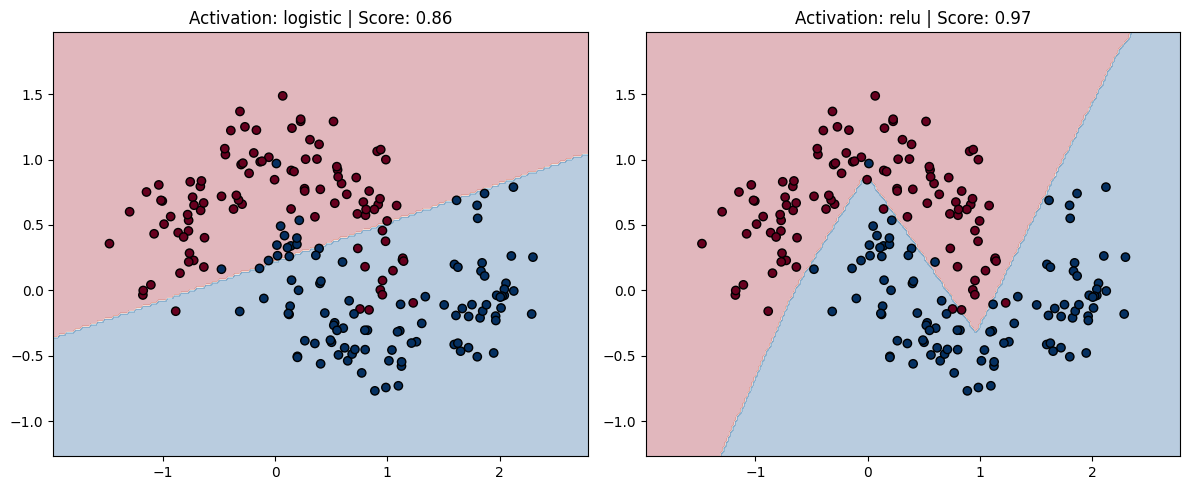

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

# 1. Generate Non-Linear "Moons" Data
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# 2. Compare Activations: Sigmoid vs ReLU
# We will use a small MLP: Hidden Layer Sizes = (10, 10)
activations = ['logistic', 'relu'] # 'logistic' is Sigmoid in sklearn
results = {}

plt.figure(figsize=(12, 5))

for i, act in enumerate(activations):
    # Initialize MLP -
    # max_iter is low to observe early learning behavior
    mlp = MLPClassifier(hidden_layer_sizes=(10, 10), activation=act,
                        max_iter=500, learning_rate_init=0.01, random_state=1)

    mlp.fit(X, y)

    # Plot Decision Boundary
    plt.subplot(1, 2, i+1)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdBu')
    plt.title(f"Activation: {act} | Score: {mlp.score(X, y):.2f}")

plt.tight_layout()
plt.show()



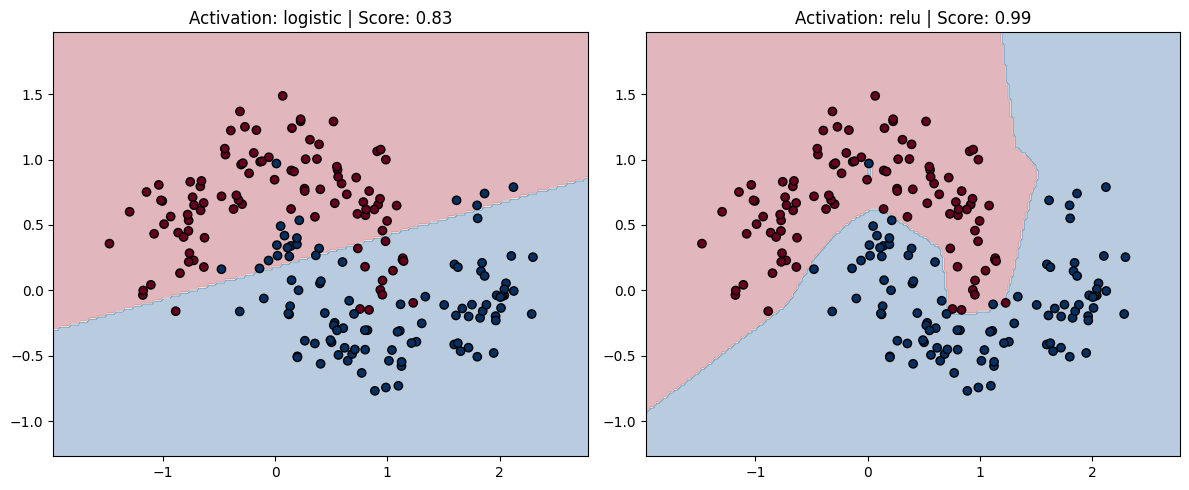

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier

# 1. Generate Non-Linear "Moons" Data
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# 2. Compare Activations: Sigmoid vs ReLU
# We will use a larger MLP: Hidden Layer Sizes = (100, 100)
activations = ['logistic', 'relu'] # 'logistic' is Sigmoid in sklearn
results = {}

plt.figure(figsize=(12, 5))

for i, act in enumerate(activations):
    # Initialize MLP -
    # max_iter is low to observe early learning behavior
    mlp = MLPClassifier(hidden_layer_sizes=(100, 100), activation=act,
                        max_iter=500, learning_rate_init=0.01, random_state=1)

    mlp.fit(X, y)

    # Plot Decision Boundary
    plt.subplot(1, 2, i+1)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5 
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), 
                         np.arange(y_min, y_max, 0.02))
    Z = mlp.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdBu')
    plt.title(f"Activation: {act} | Score: {mlp.score(X, y):.2f}")

plt.tight_layout()
plt.show()

